🚀 MEMULAI BENCHMARK OTOMATIS...

⏳ Menembak Monolitik (Kecil)...
✅ Selesai! Req/Sec: 1205.41 | Latency: 20.26 ms
⏳ Menembak Polyglot (Kecil)...
✅ Selesai! Req/Sec: 1002.6 | Latency: 24.46 ms
⏳ Menembak Monolitik (Menengah)...
✅ Selesai! Req/Sec: 199.1 | Latency: 124.74 ms
⏳ Menembak Polyglot (Menengah)...
✅ Selesai! Req/Sec: 1412.3 | Latency: 17.21 ms
⏳ Menembak Monolitik (Besar)...
✅ Selesai! Req/Sec: 29.1 | Latency: 828.98 ms
⏳ Menembak Polyglot (Besar)...
✅ Selesai! Req/Sec: 1451.2 | Latency: 16.73 ms


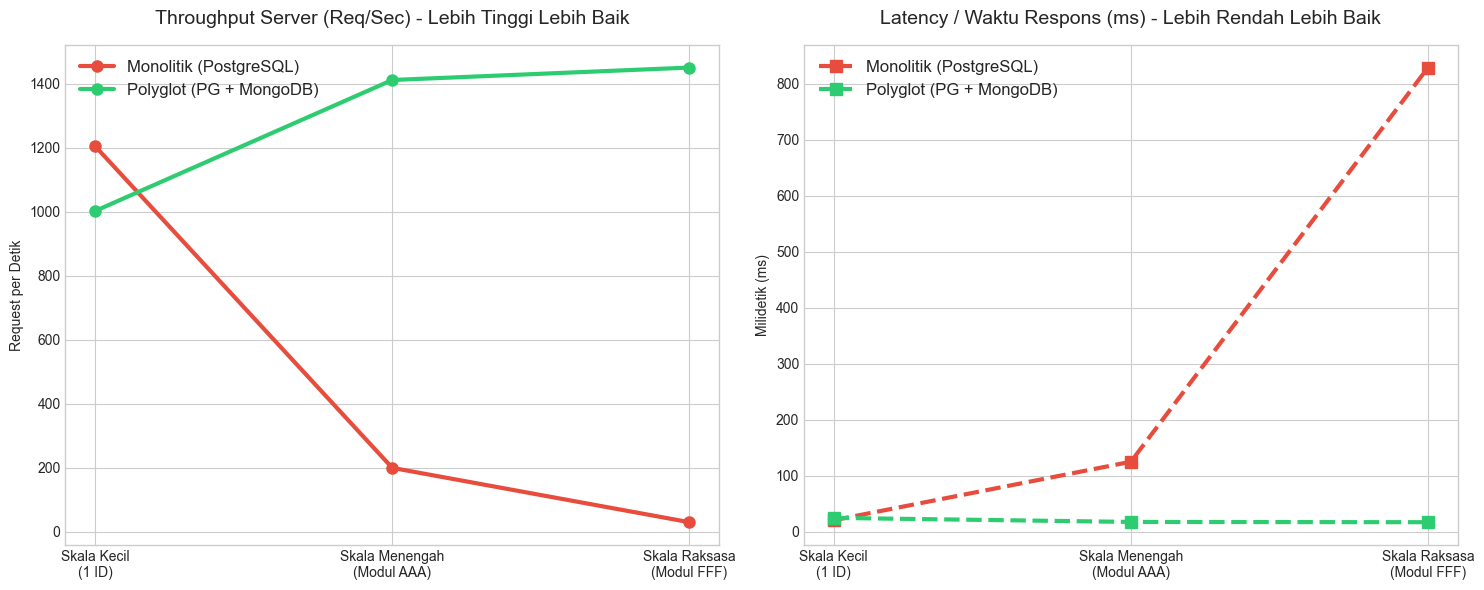

In [3]:
import subprocess
import json
import matplotlib.pyplot as plt
import pandas as pd

# Fungsi untuk memanggil Autocannon Node.js dari dalam Python
def run_autocannon(name, url, connections=25, duration=10):
    print(f"⏳ Menembak {name}...")
    # Kita tambahkan flag --json agar outputnya bisa dibaca Python
    cmd = f"npx autocannon -c {connections} -d {duration} --json {url}"
    
    # Jalankan perintah di terminal secara background
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    
    try:
        data = json.loads(result.stdout)
        req_sec = data['requests']['average']
        latency = data['latency']['average']
        print(f"✅ Selesai! Req/Sec: {req_sec} | Latency: {latency} ms")
        return req_sec, latency
    except Exception as e:
        print(f"❌ Error pada {name}: {e}")
        return 0, 0

print("🚀 MEMULAI BENCHMARK OTOMATIS...\n")

# 1. Eksekusi Skenario
scenarios = ["Skala Kecil\n(1 ID)", "Skala Menengah\n(Modul AAA)", "Skala Raksasa\n(Modul FFF)"]

mono_req, mono_lat = [], []
poly_req, poly_lat = [], []

# Skala Kecil
r, l = run_autocannon('Monolitik (Kecil)', 'http://localhost:3000/api/baseline/11391')
mono_req.append(r); mono_lat.append(l)
r, l = run_autocannon('Polyglot (Kecil)', 'http://localhost:3000/api/polyglot/11391')
poly_req.append(r); poly_lat.append(l)

# Skala Menengah
r, l = run_autocannon('Monolitik (Menengah)', 'http://localhost:3000/api/baseline-heavy/AAA/2013J')
mono_req.append(r); mono_lat.append(l)
r, l = run_autocannon('Polyglot (Menengah)', 'http://localhost:3000/api/polyglot-heavy/AAA/2013J')
poly_req.append(r); poly_lat.append(l)

# Skala Raksasa
r, l = run_autocannon('Monolitik (Besar)', 'http://localhost:3000/api/baseline-heavy/FFF/2013J')
mono_req.append(r); mono_lat.append(l)
r, l = run_autocannon('Polyglot (Besar)', 'http://localhost:3000/api/polyglot-heavy/FFF/2013J')
poly_req.append(r); poly_lat.append(l)

# 2. Visualisasi dengan Matplotlib (Line Chart)
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Grafik Throughput (Req/Sec)
ax1.plot(scenarios, mono_req, marker='o', markersize=8, linewidth=3, label='Monolitik (PostgreSQL)', color='#e74c3c')
ax1.plot(scenarios, poly_req, marker='o', markersize=8, linewidth=3, label='Polyglot (PG + MongoDB)', color='#2ecc71')
ax1.set_title('Throughput Server (Req/Sec) - Lebih Tinggi Lebih Baik', fontsize=14, pad=15)
ax1.set_ylabel('Request per Detik')
ax1.legend(fontsize=12)

# Grafik Latency (ms)
ax2.plot(scenarios, mono_lat, marker='s', markersize=8, linewidth=3, linestyle='--', label='Monolitik (PostgreSQL)', color='#e74c3c')
ax2.plot(scenarios, poly_lat, marker='s', markersize=8, linewidth=3, linestyle='--', label='Polyglot (PG + MongoDB)', color='#2ecc71')
ax2.set_title('Latency / Waktu Respons (ms) - Lebih Rendah Lebih Baik', fontsize=14, pad=15)
ax2.set_ylabel('Milidetik (ms)')
ax2.legend(fontsize=12)

plt.tight_layout()
plt.show()

MEMULAI BENCHMARK: Baseline (Monolitik) vs Polyglot Persistence

Sedang Menembak Baseline (Monolitik) (15 Detik)...
Selesai! Throughput: 7 Req/s | Latency: 3209.2 ms

Jeda 10 detik untuk pendinginan CPU (Cooldown)...
Sedang Menembak Polyglot Persistence (15 Detik)...
Selesai! Throughput: 1456.67 Req/s | Latency: 16.68 ms



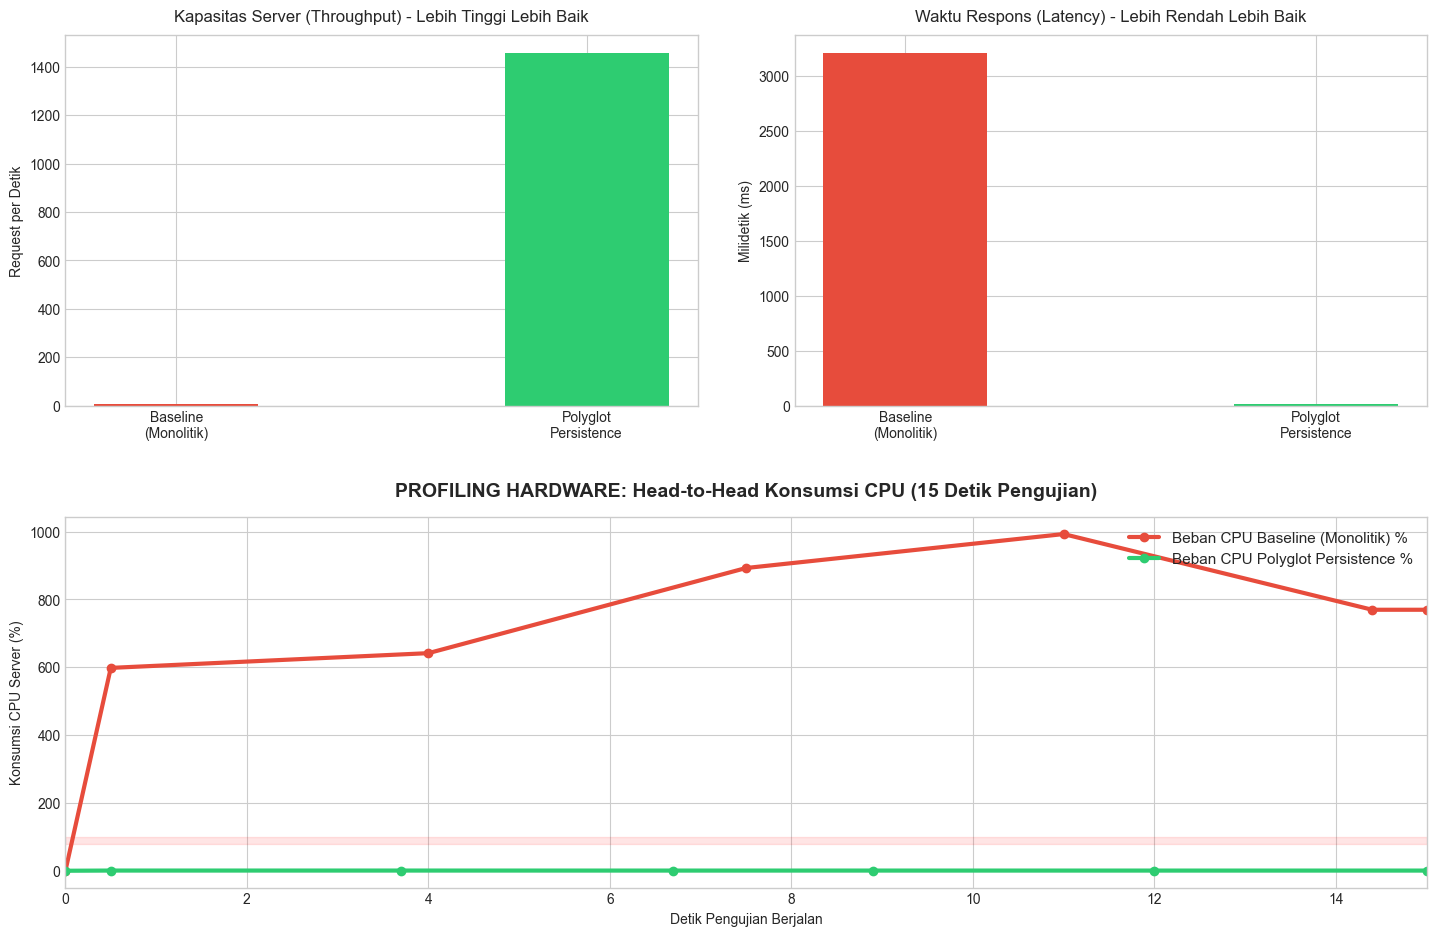

In [2]:
import subprocess
import json
import matplotlib.pyplot as plt
import threading
import time

# --- 1. SETUP DOCKER MONITORING ---
cpu_data = []
is_monitoring = False
target_db = ""

def monitor_cpu():
    global is_monitoring, cpu_data, target_db
    start_time = time.time()
    
    while is_monitoring:
        try:
            res = subprocess.run('docker stats --no-stream --format "{{.Name}},{{.CPUPerc}}"', shell=True, capture_output=True, text=True)
            lines = res.stdout.strip().split('\n')
            
            cpu_usage = 0.0
            for line in lines:
                if target_db in line.lower():
                    cpu_usage = float(line.split(',')[1].replace('%', ''))
                    break
                    
            elapsed = round(time.time() - start_time, 1)
            cpu_data.append((elapsed, cpu_usage))
        except Exception:
            pass
        time.sleep(0.5)

# --- 2. FUNGSI TIME-SHIFT & NORMALISASI ---
def normalize_data(raw_data):
    if not raw_data: return []
    clean_data = []
    
    # Menghitung delay awal (Cold Start Docker)
    offset_delay = raw_data[0][0]
    
    # Paksa mulai dari 0.0
    clean_data.append((0.0, 0.0))
    
    # Geser waktu agar sinkron di Detik 0
    for t, c in raw_data:
        shifted_time = t - offset_delay + 0.5
        if 0 < shifted_time <= 15:
            clean_data.append((shifted_time, c))
            
    # Paksa berhenti tepat di Detik 15
    if len(clean_data) > 0:
        last_cpu = clean_data[-1][1]
        if clean_data[-1][0] < 15.0:
            clean_data.append((15.0, last_cpu))
        
    return clean_data

# --- 3. FUNGSI PENEMBAK & PEREKAM ---
def run_test_and_monitor(name, url, db_keyword):
    global is_monitoring, cpu_data, target_db
    print(f"Sedang Menembak {name} (15 Detik)...")
    
    cpu_data = []
    target_db = db_keyword
    is_monitoring = True
    
    monitor_thread = threading.Thread(target=monitor_cpu)
    monitor_thread.start()
    
    cmd = f"npx autocannon -c 25 -d 15 --json {url}"
    res = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    
    is_monitoring = False
    monitor_thread.join()
    
    final_cpu_data = normalize_data(cpu_data)
    
    try:
        data = json.loads(res.stdout)
        req_sec = data['requests']['average']
        latency = data['latency']['average']
        print(f"Selesai! Throughput: {req_sec} Req/s | Latency: {latency} ms\n")
        return req_sec, latency, final_cpu_data
    except:
        print(f"Server Error/Choking parah di {name}")
        return 0, 0, final_cpu_data

# --- 4. EKSEKUSI SKENARIO ---
print("MEMULAI BENCHMARK: Baseline (Monolitik) vs Polyglot Persistence\n")

# Tes Baseline
mono_req, mono_lat, mono_cpu = run_test_and_monitor('Baseline (Monolitik)', 'http://localhost:3000/api/baseline-complex/FFF/2013J', 'postgres')

print("Jeda 10 detik untuk pendinginan CPU (Cooldown)...")
time.sleep(10)

# Tes Polyglot
poly_req, poly_lat, poly_cpu = run_test_and_monitor('Polyglot Persistence', 'http://localhost:3000/api/polyglot-complex/FFF/2013J', 'mongo')

# --- 5. VISUALISASI HASIL AKHIR ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(15, 10))

ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 1, 2)

# Konfigurasi Label
names = ['Baseline\n(Monolitik)', 'Polyglot\nPersistence']

# Grafik Throughput
ax1.bar(names, [mono_req, poly_req], color=['#e74c3c', '#2ecc71'], width=0.4)
ax1.set_title('Kapasitas Server (Throughput) - Lebih Tinggi Lebih Baik', fontsize=12, pad=10)
ax1.set_ylabel('Request per Detik')

# Grafik Latency
ax2.bar(names, [mono_lat, poly_lat], color=['#e74c3c', '#2ecc71'], width=0.4)
ax2.set_title('Waktu Respons (Latency) - Lebih Rendah Lebih Baik', fontsize=12, pad=10)
ax2.set_ylabel('Milidetik (ms)')

# GRAFIK HEAD-TO-HEAD CPU USAGE
if mono_cpu:
    m_x, m_y = zip(*mono_cpu)
    ax3.plot(m_x, m_y, label='Beban CPU Baseline (Monolitik) %', color='#e74c3c', linewidth=3, marker='o')
    
if poly_cpu:
    p_x, p_y = zip(*poly_cpu)
    ax3.plot(p_x, p_y, label='Beban CPU Polyglot Persistence %', color='#2ecc71', linewidth=3, marker='o')

ax3.set_title('PROFILING HARDWARE: Head-to-Head Konsumsi CPU (15 Detik Pengujian)', fontsize=14, pad=15, fontweight='bold')
ax3.set_xlabel('Detik Pengujian Berjalan')
ax3.set_ylabel('Konsumsi CPU Server (%)')

ax3.set_xlim(0, 15) 
ax3.legend(loc='upper right', fontsize=11)

# Zona Bahaya
ax3.axhspan(80, 100, color='red', alpha=0.1, label='Zona Berbahaya (Rawan Crash)')

try:
    plt.tight_layout(pad=3.0)
except Exception:
    pass

plt.show()